# Week 7
- Linear AE
- Non-Linear AE
-----
- Data : Lying(normal), Sitting(abnormal)

위의 data와 알고리즘을 활용해 이상치 탐지를 해본다.

In [286]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

## Data Preparation
- Train data : normal data로 한다.
- Test data : mixed (normal + abnormal) 을 사용하여 이상치 탐지를 해본다.

In [289]:
df = pd.read_csv('../dataset/DSA_features.csv')

df.head()

,T_xacc_mean,T_xacc_max,T_xacc_min,T_xacc_var,T_xacc_std,T_xacc_skew,T_yacc_mean,T_yacc_max,T_yacc_min,T_yacc_var,...,LL_ymag_std,LL_ymag_skew,LL_zmag_mean,LL_zmag_max,LL_zmag_min,LL_zmag_var,LL_zmag_std,LL_zmag_skew,activity,people
0,7.975714,8.1605,7.6823,0.014395,0.119981,-0.023319,1.083150,1.1832,0.99744,0.002208,...,0.000792,0.177075,-0.057119,-0.054963,-0.059241,6.778722e-07,0.000823,0.036729,sitting,p1
1,7.978250,8.1763,7.8472,0.007551,0.086896,0.552416,1.140865,1.2129,1.05810,0.000784,...,0.000860,-0.286918,-0.057268,-0.054945,-0.059589,7.032302e-07,0.000839,0.347471,sitting,p1
2,7.970894,8.0860,7.8470,0.003092,0.055603,0.100538,1.140962,1.2128,1.07960,0.000508,...,0.000762,-0.134430,-0.057068,-0.054711,-0.059065,6.268222e-07,0.000792,0.045579,sitting,p1
3,7.938412,8.1083,7.6901,0.003763,0.061343,-0.231914,1.165260,1.3170,1.07870,0.002173,...,0.000735,0.021485,-0.056422,-0.053670,-0.058310,8.011245e-07,0.000895,0.240690,sitting,p1
4,7.908930,8.1305,7.8322,0.001741,0.041731,2.042285,1.187504,1.2574,1.09450,0.000662,...,0.000824,-0.148229,-0.055801,-0.053313,-0.057815,6.853423e-07,0.000828,0.258429,sitting,p1


In [290]:
df.describe()

,T_xacc_mean,T_xacc_max,T_xacc_min,T_xacc_var,T_xacc_std,T_xacc_skew,T_yacc_mean,T_yacc_max,T_yacc_min,T_yacc_var,...,LL_ymag_min,LL_ymag_var,LL_ymag_std,LL_ymag_skew,LL_zmag_mean,LL_zmag_max,LL_zmag_min,LL_zmag_var,LL_zmag_std,LL_zmag_skew
count,9120.000000,9120.000000,9120.000000,9120.000000,9120.000000,9120.000000,9120.000000,9120.000000,9120.000000,9120.000000,...,9120.000000,9.120000e+03,9120.000000,9120.000000,9120.000000,9120.000000,9120.000000,9.120000e+03,9120.000000,9120.000000
mean,7.765766,14.625536,3.602974,17.807013,2.454290,0.305587,-0.811036,1.801847,-3.704204,2.049747,...,0.111347,1.818862e-02,0.105897,-0.055440,0.064504,0.169687,-0.052866,7.624694e-03,0.059342,-0.089861
std,3.758022,11.823448,5.622855,45.188787,3.432895,0.768360,2.201692,4.177165,3.982579,3.908675,...,0.362373,2.382393e-02,0.083518,0.526959,0.346660,0.360190,0.359712,1.903445e-02,0.064059,0.619636
min,-11.575660,-4.758700,-99.715000,0.000135,0.011633,-7.826631,-9.782885,-9.703600,-49.941000,0.000141,...,-0.901760,3.044156e-07,0.000552,-3.693948,-0.912397,-0.910830,-1.126000,2.960874e-07,0.000544,-5.111532
25%,8.374161,9.523200,0.000000,0.036855,0.191977,-0.161535,-1.134192,0.172375,-4.837875,0.012121,...,-0.111835,5.683172e-04,0.023839,-0.343123,-0.156271,-0.035821,-0.326125,2.227543e-04,0.014925,-0.402781
50%,9.186328,12.549500,5.757900,2.241468,1.497153,0.275042,-0.375678,1.571750,-2.470150,0.737663,...,0.184470,1.078612e-02,0.103856,-0.075786,0.086285,0.210825,-0.040447,1.813539e-03,0.042586,-0.092036
75%,9.515573,15.843250,7.649075,6.680571,2.584680,0.845410,0.127612,3.005450,-1.279725,1.900426,...,0.315962,2.740661e-02,0.165549,0.177076,0.295415,0.422270,0.206933,6.927870e-03,0.083234,0.228493
max,10.713139,93.694000,9.749000,392.898630,19.821671,9.070164,7.051530,41.013000,2.656400,54.332000,...,0.969020,3.041940e-01,0.551538,5.035185,1.020691,1.042600,0.999440,2.790198e-01,0.528223,3.560828


In [291]:
# Null값 확인
df.isna().values.any()

False

In [292]:
np.unique(df['activity'], return_counts=True)

(array(['ascendingStairs', 'basketBall', 'crossTrainer',
        'cyclingHorizontal', 'cyclingVertical', 'decendingStairs',
        'jumping', 'lyingBack', 'lyingRigh', 'movingInElevator', 'rowing',
        'runningTreadmill', 'sitting', 'standing',
        'standingInElevatorStill', 'stepper', 'walkingLot',
        'walkingTreadmillFlat', 'walkingTreadmillIncline'], dtype=object),
 array([480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480, 480,
        480, 480, 480, 480, 480, 480], dtype=int64))

In [293]:
# 관심있는 3가지 activity 추출
df = df.loc[df['activity'].isin(['lyingRigh', 'lyingBack', 'sitting'])]
df['activity'].value_counts()

activity
sitting      480
lyingBack    480
lyingRigh    480
Name: count, dtype: int64

In [294]:
df.shape

(1440, 272)

### labeling  
sitting - abnormal, lying - normal

In [297]:
df['class'] = df['activity'].apply(lambda x: 'normal' if x.startswith('lying') else 'abnormal')
df.columns

Index(['T_xacc_mean', 'T_xacc_max', 'T_xacc_min', 'T_xacc_var', 'T_xacc_std',
       'T_xacc_skew', 'T_yacc_mean', 'T_yacc_max', 'T_yacc_min', 'T_yacc_var',
       ...
       'LL_ymag_skew', 'LL_zmag_mean', 'LL_zmag_max', 'LL_zmag_min',
       'LL_zmag_var', 'LL_zmag_std', 'LL_zmag_skew', 'activity', 'people',
       'class'],
      dtype='object', length=273)

C:\Users\user\AppData\Local\Temp\ipykernel_13080\4092775785.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['class'], sort = True)


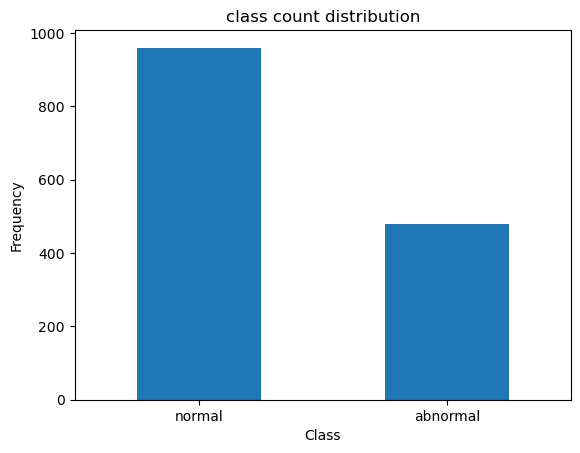

class
normal      960
abnormal    480
Name: count, dtype: int64

In [298]:
count_classes = pd.value_counts(df['class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("class count distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

df['class'].value_counts()

In [299]:
df.head()

,T_xacc_mean,T_xacc_max,T_xacc_min,T_xacc_var,T_xacc_std,T_xacc_skew,T_yacc_mean,T_yacc_max,T_yacc_min,T_yacc_var,...,LL_ymag_skew,LL_zmag_mean,LL_zmag_max,LL_zmag_min,LL_zmag_var,LL_zmag_std,LL_zmag_skew,activity,people,class
0,7.975714,8.1605,7.6823,0.014395,0.119981,-0.023319,1.083150,1.1832,0.99744,0.002208,...,0.177075,-0.057119,-0.054963,-0.059241,6.778722e-07,0.000823,0.036729,sitting,p1,abnormal
1,7.978250,8.1763,7.8472,0.007551,0.086896,0.552416,1.140865,1.2129,1.05810,0.000784,...,-0.286918,-0.057268,-0.054945,-0.059589,7.032302e-07,0.000839,0.347471,sitting,p1,abnormal
2,7.970894,8.0860,7.8470,0.003092,0.055603,0.100538,1.140962,1.2128,1.07960,0.000508,...,-0.134430,-0.057068,-0.054711,-0.059065,6.268222e-07,0.000792,0.045579,sitting,p1,abnormal
3,7.938412,8.1083,7.6901,0.003763,0.061343,-0.231914,1.165260,1.3170,1.07870,0.002173,...,0.021485,-0.056422,-0.053670,-0.058310,8.011245e-07,0.000895,0.240690,sitting,p1,abnormal
4,7.908930,8.1305,7.8322,0.001741,0.041731,2.042285,1.187504,1.2574,1.09450,0.000662,...,-0.148229,-0.055801,-0.053313,-0.057815,6.853423e-07,0.000828,0.258429,sitting,p1,abnormal


In [304]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [307]:
le.classes_

array(['abnormal', 'normal'], dtype=object)

In [308]:
data = df.drop(['activity', 'people'], axis=1)
data.head()

,T_xacc_mean,T_xacc_max,T_xacc_min,T_xacc_var,T_xacc_std,T_xacc_skew,T_yacc_mean,T_yacc_max,T_yacc_min,T_yacc_var,...,LL_ymag_var,LL_ymag_std,LL_ymag_skew,LL_zmag_mean,LL_zmag_max,LL_zmag_min,LL_zmag_var,LL_zmag_std,LL_zmag_skew,class
0,7.975714,8.1605,7.6823,0.014395,0.119981,-0.023319,1.083150,1.1832,0.99744,0.002208,...,6.267229e-07,0.000792,0.177075,-0.057119,-0.054963,-0.059241,6.778722e-07,0.000823,0.036729,0
1,7.978250,8.1763,7.8472,0.007551,0.086896,0.552416,1.140865,1.2129,1.05810,0.000784,...,7.403458e-07,0.000860,-0.286918,-0.057268,-0.054945,-0.059589,7.032302e-07,0.000839,0.347471,0
2,7.970894,8.0860,7.8470,0.003092,0.055603,0.100538,1.140962,1.2128,1.07960,0.000508,...,5.802523e-07,0.000762,-0.134430,-0.057068,-0.054711,-0.059065,6.268222e-07,0.000792,0.045579,0
3,7.938412,8.1083,7.6901,0.003763,0.061343,-0.231914,1.165260,1.3170,1.07870,0.002173,...,5.398837e-07,0.000735,0.021485,-0.056422,-0.053670,-0.058310,8.011245e-07,0.000895,0.240690,0
4,7.908930,8.1305,7.8322,0.001741,0.041731,2.042285,1.187504,1.2574,1.09450,0.000662,...,6.787533e-07,0.000824,-0.148229,-0.055801,-0.053313,-0.057815,6.853423e-07,0.000828,0.258429,0


In [311]:
# Train, Test split
X_train, X_test = train_test_split(data, test_size=0.2, random_state=42)

# Train data : normal data
X_train = X_train[X_train['class'] == 1]
X_train = X_train.drop(['class'], axis=1)

# Test data : mixed data
y_test = X_test['class'].values
X_test = X_test.drop(['class'], axis=1)

In [312]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train = ss.fit_transform(X_train) 
X_test = ss.transform(X_test) 

### Structure Model

In [317]:
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [400]:
# 오토인코더
def construct_model(input_size, mode):
    
    input_layer = Input(shape=(input_dim,))
    
    encoded = Dense(64, activation='relu')(input_layer)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dense(16, activation='relu')(encoded)
    
    if (mode == 'linear'):
        decoded = Dense(32, activation='relu')(encoded)
        decoded = Dense(64, activation='relu')(decoded)
        
    elif (mode == 'non-linear'):
        decoded = Dense(64, activation='relu')(encoded)
        decoded = Dense(128, activation='relu')(decoded)
        
    decoded = Dense(input_dim, activation='sigmoid')(decoded)
    return Model(inputs=input_layer, outputs=decoded)

## Linear AE

In [403]:
input_dim = X_train.shape[1]

autoencoder = construct_model(input_dim, 'linear')
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 270)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_55 (Dense)                     │ (None, 64)                  │          17,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_56 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_57 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_58 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_59 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_60 (Dense)                     │ (None, 270)                 │          17,550 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,158 (156.87 KB)

 Trainable params: 40,158 (156.87 KB)

 Non-trainable params: 0 (0.00 B)

In [405]:
# 3. 모델 학습
# 훈련데이터의 0.1 을 validation data로 사용
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = autoencoder.fit(X_train, X_train, 
                          epochs=50, 
                          batch_size=32, 
                          shuffle=True, 
                          callbacks=[early_stopping_cb],
                          validation_split = 0.1)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.4778 - val_loss: 1.5933
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4245 - val_loss: 1.3957
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0273 - val_loss: 1.3439
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8052 - val_loss: 1.3107
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6696 - val_loss: 1.2870
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8631 - val_loss: 1.2754
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7338 - val_loss: 1.2687
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6900 - val_loss: 1.2629
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5888 - val_loss: 1.2596
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8429 - val_loss: 1.2552
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0914 - val_loss: 1.2513
Epoch 12/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8661 - val_l

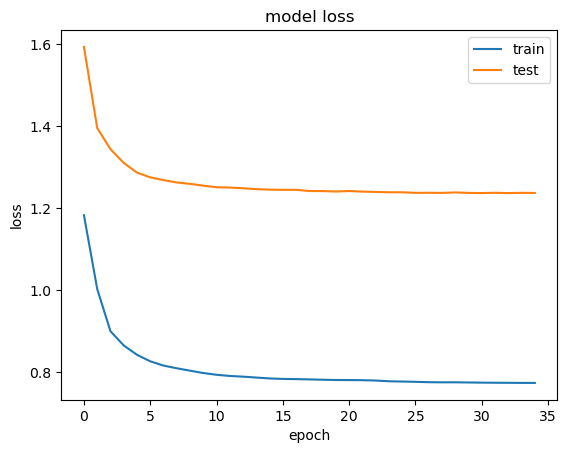

In [406]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right');

In [407]:
# X_test 값을 넣어서 Reconstruction Error 값을 얻고,
# 실제 레이블인 y_test와 데이터프레임으로 구성
# Reconstruction Error + 실제 레이블의 형태가 됨

predictions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - predictions, 2), axis=1) # reconstruction error
error_df = pd.DataFrame({'reconstruction_error': mse,
                        'true_class': y_test})
error_df.describe()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


,reconstruction_error,true_class
count,288.000000,288.000000
mean,4.066047,0.684028
std,46.512077,0.465711
min,0.142160,0.000000
25%,0.315866,0.000000
50%,0.456702,1.000000
75%,0.813271,1.000000
max,778.541687,1.000000


In [408]:
error_df.head()

,reconstruction_error,true_class
0,0.960287,0
1,0.464982,1
2,0.607448,1
3,1.280217,0
4,0.437378,1


In [449]:
threshold = 0.7

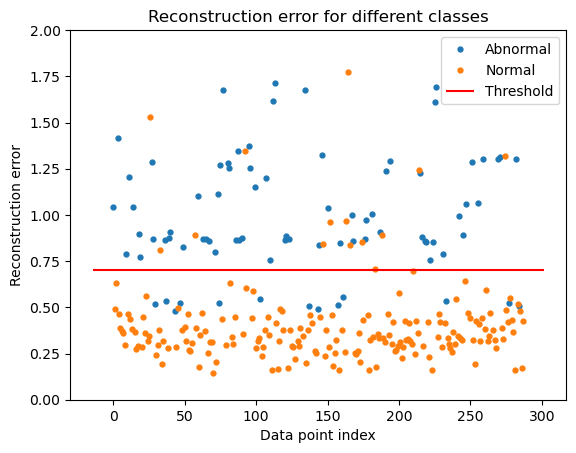

In [451]:
import matplotlib.pyplot as plt
groups = error_df.groupby('true_class')
fig, ax = plt.subplots()
ax.set_ylim(0, 2)

for name, group in groups:
    ax.plot(group.index, group.reconstruction_error, marker='o', ms=3.5, linestyle='',
            label= "Abnormal" if name == 0 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Reconstruction error for different classes")
plt.ylabel("Reconstruction error")
plt.xlabel("Data point index")
plt.show();

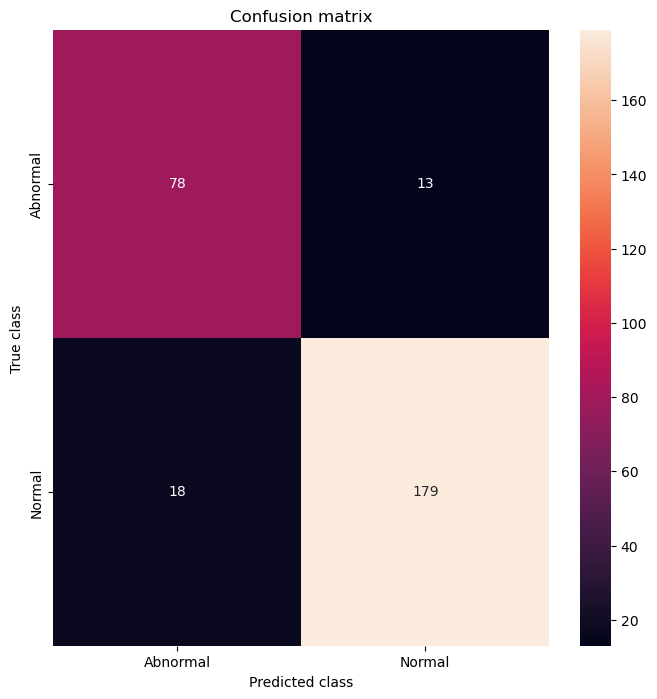

              precision    recall  f1-score   support

           0       0.81      0.86      0.83        91
           1       0.93      0.91      0.92       197

    accuracy                           0.89       288
   macro avg       0.87      0.88      0.88       288
weighted avg       0.89      0.89      0.89       288



In [453]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = [0 if e > threshold else 1 for e in error_df.reconstruction_error.values]
conf_matrix = confusion_matrix(error_df.true_class, y_pred)
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, xticklabels=['Abnormal', 'Normal'], yticklabels=['Abnormal', 'Normal'], annot=True, fmt="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

print(classification_report(error_df.true_class, y_pred))

## Non-linear

In [456]:
autoencoder = construct_model(input_dim, 'non-linear')
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)          │ (None, 270)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 64)                  │          17,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_70 (Dense)                     │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_71 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_72 (Dense)                     │ (None, 270)                 │          34,830 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,190 (250.74 KB)

 Trainable params: 64,190 (250.74 KB)

 Non-trainable params: 0 (0.00 B)

In [458]:
# 3. 모델 학습
# 훈련데이터의 0.1 을 validation data로 사용
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = autoencoder.fit(X_train, X_train, 
                          epochs=50, 
                          batch_size=32, 
                          shuffle=True, 
                          callbacks=[early_stopping_cb],
                          validation_split = 0.1)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.3224 - val_loss: 1.5286
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9316 - val_loss: 1.3638
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9394 - val_loss: 1.3330
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7856 - val_loss: 1.3024
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1772 - val_loss: 1.2712
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8508 - val_loss: 1.2536
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5434 - val_loss: 1.2444
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7546 - val_loss: 1.2390
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7986 - val_loss: 1.2354
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7261 - val_loss: 1.2325
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6562 - val_loss: 1.2325
Epoch 12/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6196 - val_l

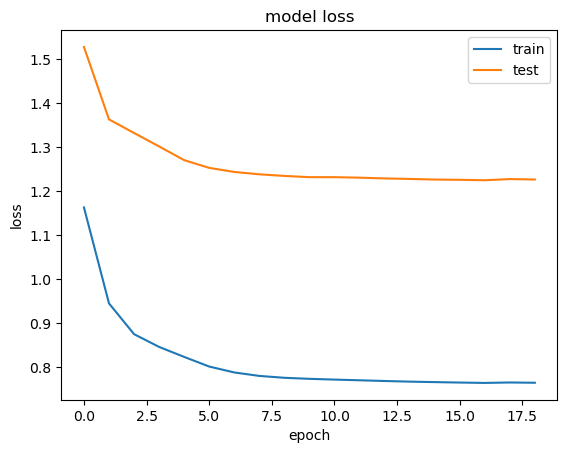

In [459]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right');

In [460]:
# X_test 값을 넣어서 Reconstruction Error 값을 얻고,
# 실제 레이블인 y_test와 데이터프레임으로 구성
# Reconstruction Error + 실제 레이블의 형태가 됨

predictions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - predictions, 2), axis=1) # reconstruction error
error_df = pd.DataFrame({'reconstruction_error': mse,
                        'true_class': y_test})
error_df.describe()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


,reconstruction_error,true_class
count,288.000000,288.000000
mean,4.072432,0.684028
std,46.519033,0.465711
min,0.141485,0.000000
25%,0.301031,0.000000
50%,0.442235,1.000000
75%,0.868302,1.000000
max,778.667666,1.000000


In [461]:
error_df.head()

,reconstruction_error,true_class
0,0.997176,0
1,0.470805,1
2,0.615069,1
3,1.373771,0
4,0.432925,1


In [462]:
threshold=0.7

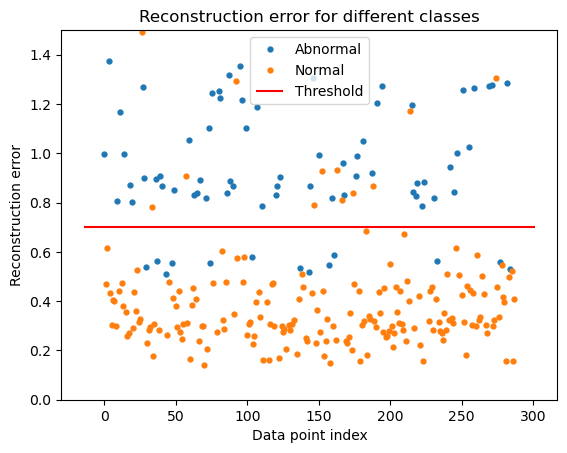

In [463]:
import matplotlib.pyplot as plt
groups = error_df.groupby('true_class')
fig, ax = plt.subplots()
ax.set_ylim(0, 1.5)

for name, group in groups:
    ax.plot(group.index, group.reconstruction_error, marker='o', ms=3.5, linestyle='',
            label= "Abnormal" if name == 0 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Reconstruction error for different classes")
plt.ylabel("Reconstruction error")
plt.xlabel("Data point index")
plt.show();

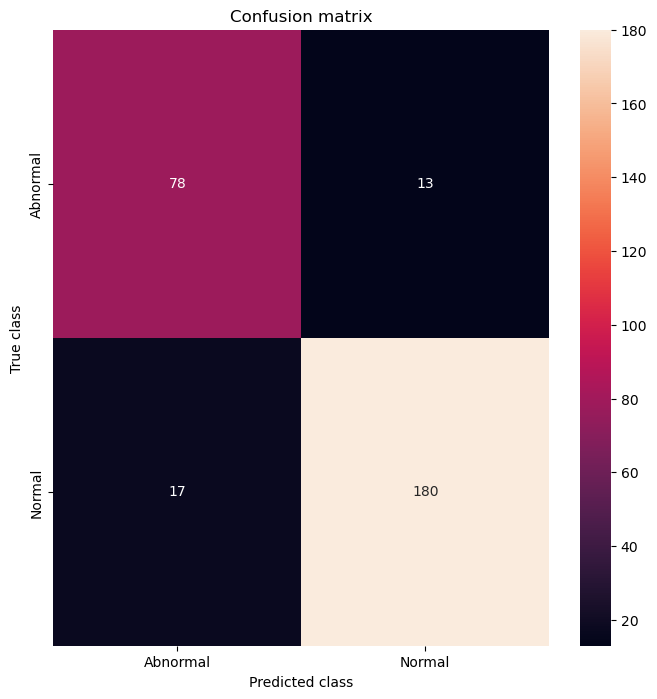

              precision    recall  f1-score   support

           0       0.82      0.86      0.84        91
           1       0.93      0.91      0.92       197

    accuracy                           0.90       288
   macro avg       0.88      0.89      0.88       288
weighted avg       0.90      0.90      0.90       288



In [470]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = [0 if e > threshold else 1 for e in error_df.reconstruction_error.values]
conf_matrix = confusion_matrix(error_df.true_class, y_pred)
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, xticklabels=['Abnormal', 'Normal'], yticklabels=['Abnormal', 'Normal'], annot=True, fmt="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

print(classification_report(error_df.true_class, y_pred))